## Practical Lab 3 - Vanilla CNN and Fine-Tune VGG16 - for Dogs and Cats Classification

In this lab, we will work through a common practice of Deep Learning Engineers - that is - take an existing model, that does something similar to what the engineer is interested doing, and fine-tune it for the specific task at-hand.

Notice to follow a good notebook structure, and focus on readability and clarity of the code, insights and conclusions.

1. Obtain the Data: Get the Dogs vs Cats dataset (see class' notebook, only 5000, not 25,000, images are required, this image set is defined in the notebook)
2. EDA: Explore the data with relevant graphs, statistics and insights (**5 points**)
3. Train two networks (use callbacks to save the best model version):
Define a Neural Network of your choice (**3 points**)
Fine-Tune VGG16 (pre-trained on imagenet). Make sure to use validation to test for over-fitting. Plot the appropriate graph (**3 points**)
4. Explore the relative performance of the models (make sure to load the best version of each model) (**6 points**): 
   1. accuracy
   2. confusion metric
   3. precision, recall, F1-score,
   4. precision-recall curve.
   5. Explore specific examples in which the model failed to predict correctly.
5. Add your conclusions. (**3 point**)

   Generate a GitHub with your work. Push a Jupyter Notebook with your code AND Markdown, including at least five talking points for the key sections of the development process. Then generate a PDF with your names and IDs, the assignment title, and a link to the GitHub repository.

Submissions past the due date:

   * 10% deduction after 11:00 am on the due date.
   * 25% deduction after 11:59 pm on the due date.
   * No credit will be given after 11:59 p.m. on the day after the due date.

---

Academic integrity:

   * **The instructor may summon students suspected of academic dishonesty for a code review to verify their understanding and ability to reproduce any stage of the development process. The instructor reserves the right to deduct marks, either partially or entirely.**

---


In [ ]:
import os

# Auto-create output directory for saving models
output_dir = 'models'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Created folder: {output_dir}")
else:
    print(f"ℹ️ Folder '{output_dir}' already exists.")

## Obtain the Data
* The dataset used in this challenge is the Dogs vs. Cats dataset, which can be obtained from:
    * https://www.microsoft.com/en-us/download/details.aspx?id=54765
* Dataset Preparation Notes:
    * Location: The data should be unzipped and available at ../data/kaggle_dogs_vs_cats/train.
    * Path Adjustments: Note that the exact paths and the names of the image files may differ depending on the source of the dataset. The code below is adjusted to match the current directory structure.

In [1]:
import os, shutil, pathlib

# set paths
original_dir = pathlib.Path("data/kaggle_dogs_vs_cats/train/PetImages")
new_base_dir = pathlib.Path("data/dogs_vs_cats")

# reset data
# True to delete old data and create new subsets
# False to skip if data already exists
RESET_DATA = False 

# Check
if new_base_dir.exists():
    if RESET_DATA:
        shutil.rmtree(new_base_dir)
        print("RESET_DATA is True: Old data directory deleted.")
    else:
        print("Data directory already exists. Skipping subset creation to save time.")

# define a function to create subsets
def make_subset(subset_name, start_index, end_index):
    for category in ("Cat", "Dog"):
        target_dir = new_base_dir / subset_name / category
        os.makedirs(target_dir, exist_ok=True)
        
        fnames = [f"{i}.jpg" for i in range(start_index, end_index)]
        
        for fname in fnames:
            src = original_dir / category / fname
            dst = target_dir / fname
            if src.exists():
                shutil.copyfile(src, dst)

# if the new base directory doesn't exist, it means we need to create the subsets
if not new_base_dir.exists():
    print("Creating new data subsets...")
    
    # split the data into train, validation, and test sets
    make_subset("train", start_index=0, end_index=1000)  # train: 0~999
    make_subset("validation", start_index=1000, end_index=1500) # validation: 1000~1499
    make_subset("test", start_index=1500, end_index=2500) # test: 1500~2499
    print("Done! Data splitting complete.")

Data directory already exists. Skipping subset creation to save time.


## Exploratory Data Analysis (EDA)
* explore the dataset to understand the distribution of classes and visualize some sample images.

### Cleaning the Data
* When the AI tries to read a broken image, it crashes. `InvalidArgumentError Traceback (most recent call last)`
* use the `PIL` library to check every photo. If a photo is bad, we delete it.

In [2]:
import os
import PIL
from PIL import Image

# Path
base_dir = pathlib.Path("data/dogs_vs_cats")

print("Checking for corrupted images...")
num_skipped = 0

for folder in ("train", "validation", "test"):
    for category in ("Cat", "Dog"):
        folder_path = base_dir / folder / category
        for fname in os.listdir(folder_path):
            fpath = folder_path / fname
            try:
                # Try to open and verify the image
                img = Image.open(fpath)
                img.verify()
            except (IOError, SyntaxError) as e:
                #If the image is broken, delete it
                print(f"Found corrupted file and deleted: {fpath}")
                os.remove(fpath)
                num_skipped += 1

print(f"Checking complete! Deleted {num_skipped} corrupted images.")

Checking for corrupted images...
Checking complete! Deleted 0 corrupted images.


### Data Statistics

--- Data Statistics ---
train Cat: 999 images
train Dog: 1000 images
validation Cat: 500 images
validation Dog: 500 images
test Cat: 1000 images
test Dog: 1000 images


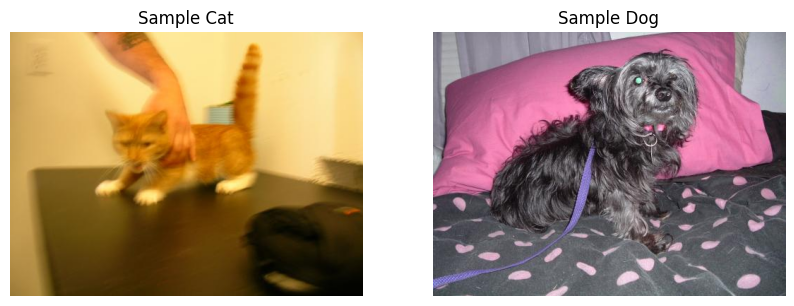

In [3]:
import matplotlib.pyplot as plt
import os

# count
def count_files(directory):
    return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])

subsets = ['train', 'validation', 'test']
categories = ['Cat', 'Dog']

print("--- Data Statistics ---")
for s in subsets:
    for c in categories:
        path = os.path.join("data/dogs_vs_cats", s, c)
        print(f"{s} {c}: {count_files(path)} images")

# Visualize sample images
import matplotlib.image as mpimg

plt.figure(figsize=(10, 5))
cat_path = "data/dogs_vs_cats/train/Cat/0.jpg"
dog_path = "data/dogs_vs_cats/train/Dog/0.jpg"

plt.subplot(1, 2, 1)
plt.imshow(mpimg.imread(cat_path))
plt.title("Sample Cat")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mpimg.imread(dog_path))
plt.title("Sample Dog")
plt.axis("off")
plt.show()

### Data Visualization (Graphs)

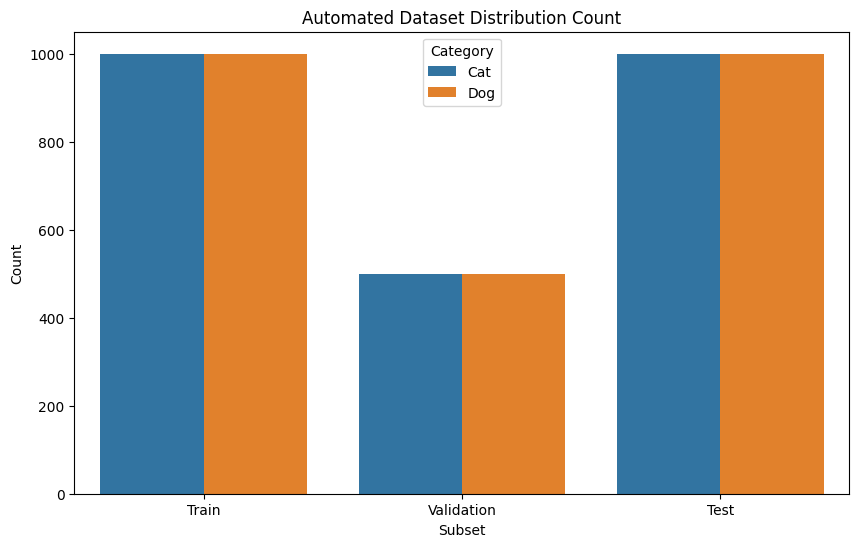

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Create the list by count_files function
subsets = ['train', 'validation', 'test']
categories = ['Cat', 'Dog']
stats_list = []

for s in subsets:
    for c in categories:
        path = os.path.join("data/dogs_vs_cats", s, c)
        count = count_files(path)
        stats_list.append({'Subset': s.capitalize(), 'Category': c, 'Count': count})

# pandas to create the DataFrame
df_stats = pd.DataFrame(stats_list)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_stats, x='Subset', y='Count', hue='Category')
plt.title("Automated Dataset Distribution Count")
plt.show()

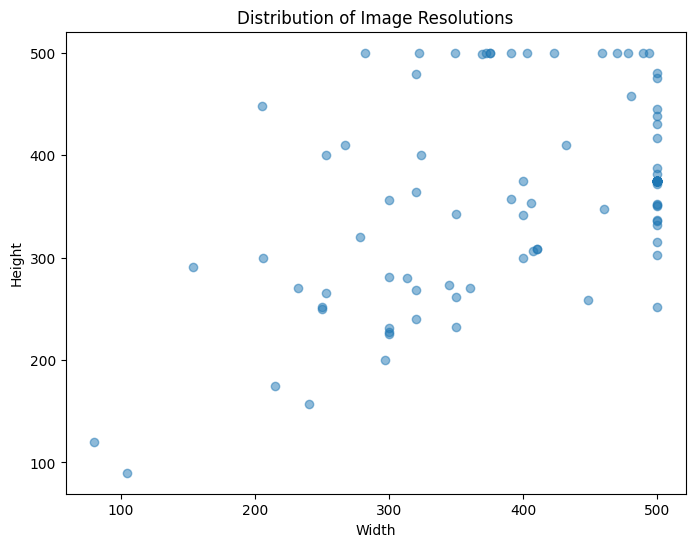

In [5]:
# Analyze image sizes of the first 100 images
widths, heights = [], []
cat_train_path = "data/dogs_vs_cats/train/Cat"

for fname in os.listdir(cat_train_path)[:100]:
    with Image.open(os.path.join(cat_train_path, fname)) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(8, 6))
plt.scatter(widths, heights, alpha=0.5)
plt.title("Distribution of Image Resolutions")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

### Sample Images

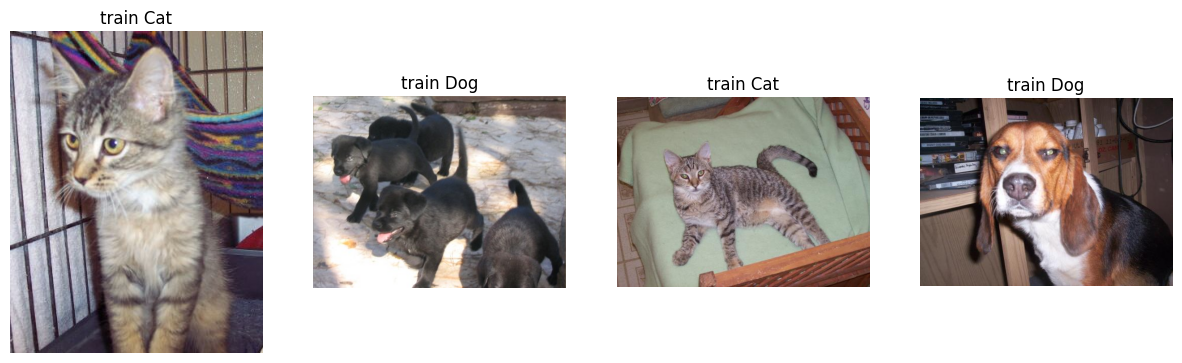

In [6]:
import random

def show_random_samples(subset="train", num_images=4):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        category = random.choice(["Cat", "Dog"])
        folder = os.path.join("data/dogs_vs_cats", subset, category)
        fname = random.choice(os.listdir(folder))
        img_path = os.path.join(folder, fname)
        
        plt.subplot(1, num_images, i+1)
        plt.imshow(mpimg.imread(img_path))
        plt.title(f"{subset} {category}")
        plt.axis("off")
    plt.show()

show_random_samples()

### Observations & Insights:
1. In the training set, there are 999 cats and 1000 dogs. This balance is crucial because it prevents the model from becoming biased toward one specific category.
2. observed that the original images have various resolutions and aspect ratios. Therefore, we must resize all images to a consistent size. This ensures that the neural network receives uniform input dimensions.
3. The samples show a high variety of backgrounds,this complexity suggests that a simple Vanilla CNN might struggle, and data augmentation will be necessary to improve generalization.
4. With only 2,000 images for training, there is a high risk of Overfitting, so will implement Data Augmentation (flipping, rotation) and use a Pre-trained VGG16 model for better performance.

## Data Loading & Preprocessing

Based on the EDA results, the following strategies will be implemented:

1. Since original images have various resolutions, all images will be resized to $180 \times 180$ pixels to ensure consistent input for the neural network.
2. use a batch size of 32 to balance memory usage and training stability.
3. utilize `tf.data API` to handle image loading. This allows the model to process data efficiently without loading all 5,000 images into memory at once.
4. Labels will be automatically inferred from the directory structure ("Cat" folder as class 0, "Dog" folder as class 1).

In [ ]:
import os
import tensorflow as tf

# Set paths
train_dir = "data/dogs_vs_cats/train"
val_dir = "data/dogs_vs_cats/validation"
test_dir = "data/dogs_vs_cats/test"

#Configuration
BATCH_SIZE = 32
DENSE_UNITS = 128
VGG_DENSE_UNITS = 256
SEED = 666

# Add a safety check before loading
if os.path.exists(train_dir):
    # Load datasets
    train_dataset = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        image_size=(180, 180),
        batch_size=BATCH_SIZE)

    validation_dataset = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=(180, 180),
        batch_size=BATCH_SIZE)

    test_dataset = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        image_size=(180, 180),
        batch_size=BATCH_SIZE)

    # Optimization
    options = tf.data.Options()
    options.threading.max_intra_op_parallelism = 1
    options.threading.private_threadpool_size = 1
    options.experimental_distribute.auto_shard_policy = tf.data.experimental.AutoShardPolicy.OFF

    train_dataset = train_dataset.with_options(options)
    validation_dataset = validation_dataset.with_options(options)
    test_dataset = test_dataset.with_options(options)

    print("Data set loading complete. Ready for training.")
else:
    print("Error: Data folders not found! Please check if 'Obtain Data' step was successful.")

Found 1999 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Data set loading complete. Ready for training.


## Define a Neural Network (Vanilla CNN)

### Data Augmentation & Rescaling
* This randomly changes the images during training to prevent overfitting.
* This changes pixel values from [0, 255] to [0, 1].

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

# Define data augmentation layers
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),    # randomly flip images horizontally
    layers.RandomRotation(0.1),       # randomly rotate images by 10%
    layers.RandomZoom(0.1),           # randomly zoom images by 10%
])

# Rescaling layer to normalize pixel values to [0, 1]
rescaling_layer = layers.Rescaling(1./255)

### Model Architecture
1. build a sequential model starting with our preprocessing layers, followed by three convolutional blocks to extract features.

In [ ]:
# Define the Model Structure
model_vanilla = tf.keras.Sequential([
    # Input Layer
    tf.keras.layers.InputLayer(input_shape=(180, 180, 3)),
    
    # Augmentation and Rescaling
    data_augmentation, 
    rescaling_layer,

    # Convolutional Base
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(DENSE_UNITS, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Display the architecture summary
model_vanilla.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 180, 180, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 89, 89, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 43, 43, 64)       0         
 2D)                                                  

### Model Compilation & Callbacks
1. use the Adam optimizer and implement a `ModelCheckpoint` to save the best version of the model based on validation loss.

In [10]:
model_vanilla.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# EDefine Callbacks to save the best model
if not os.path.exists('models'):
    os.makedirs('models')

callbacks_list = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='models/best_vanilla_model.keras',
        save_best_only=True,
        monitor='val_loss'
    )
]

print("Model compilation and callbacks are ready.")

Model compilation and callbacks are ready.


### Model Training
1. train the model for 20 epochs and visualize the training history to check for overfitting.

In [ ]:
# skips the bad photo and keeps working.
train_dataset = train_dataset.apply(tf.data.experimental.ignore_errors())
validation_dataset = validation_dataset.apply(tf.data.experimental.ignore_errors())

# training the Vanilla CNN
history_vanilla = model_vanilla.fit(
    train_dataset,
    #epochs=10,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks_list
)

Epoch 1/20
63/63 [==============================] - 21s 299ms/step - loss: 0.8383 - accuracy: 0.5008 - val_loss: 0.6904 - val_accuracy: 0.5690
Epoch 2/20
63/63 [==============================] - 20s 309ms/step - loss: 0.6836 - accuracy: 0.5468 - val_loss: 0.6629 - val_accuracy: 0.5900
Epoch 3/20
63/63 [==============================] - 20s 309ms/step - loss: 0.6644 - accuracy: 0.6123 - val_loss: 0.6511 - val_accuracy: 0.6140
Epoch 4/20
63/63 [==============================] - 22s 340ms/step - loss: 0.6293 - accuracy: 0.6528 - val_loss: 0.6159 - val_accuracy: 0.6650
Epoch 5/20
63/63 [==============================] - 21s 337ms/step - loss: 0.6126 - accuracy: 0.6768 - val_loss: 0.6009 - val_accuracy: 0.6580
Epoch 6/20
63/63 [==============================] - 22s 338ms/step - loss: 0.6051 - accuracy: 0.6843 - val_loss: 0.5822 - val_accuracy: 0.6920
Epoch 7/20
63/63 [==============================] - 22s 338ms/step - loss: 0.5814 - accuracy: 0.6938 - val_loss: 0.5867 - val_accuracy: 0.6930

###  Visualization

Contents of 'models' folder: ['best_vanilla_model.keras']
File size: 76.12 MB


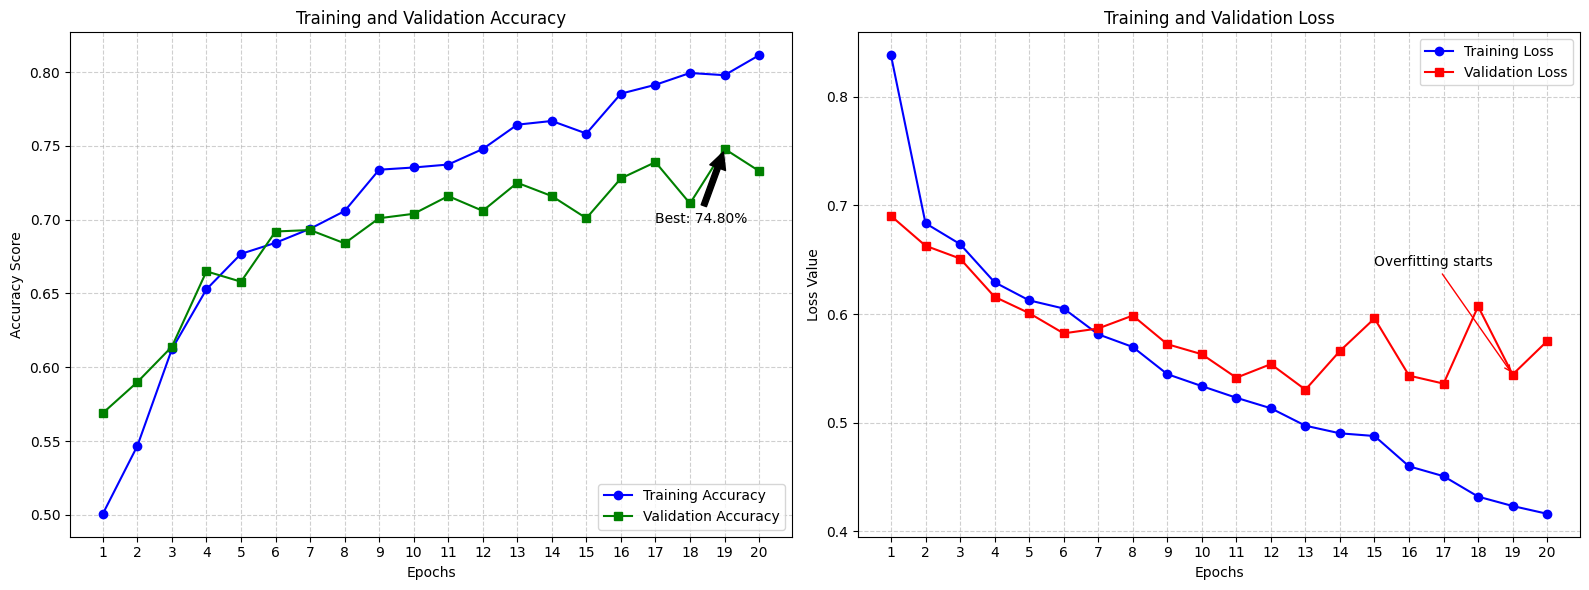

In [ ]:
import matplotlib.pyplot as plt

# Extracting data from history
acc = history_vanilla.history['accuracy']
val_acc = history_vanilla.history['val_accuracy']
loss = history_vanilla.history['loss']
val_loss = history_vanilla.history['val_loss']
epochs_range = range(1, len(acc) + 1) # 1, 2, ..., 20

# models directory
import os

if os.path.exists('models'):
    print("Contents of 'models' folder:", os.listdir('models'))
    # MB
    size = os.path.getsize('models/best_vanilla_model.keras') / (1024 * 1024)
    print(f"File size: {size:.2f} MB")
else:
    print("Directory 'models' does not exist yet. Did you run the training?")

plt.figure(figsize=(16, 6))

# --- Plot Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'bo-', label='Training Accuracy') # 'bo-' ./-
plt.plot(epochs_range, val_acc, 'gs-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs') # X
plt.ylabel('Accuracy Score') # Y
plt.xticks(epochs_range) # show 1 to 20
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Add text annotation for the best epoch
best_epoch = epochs_range[val_acc.index(max(val_acc))]
plt.annotate(f'Best: {max(val_acc):.2%}', 
             xy=(best_epoch, max(val_acc)), 
             xytext=(best_epoch-2, max(val_acc)-0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'bo-', label='Training Loss')
plt.plot(epochs_range, val_loss, 'rs-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.xticks(epochs_range)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Mark the Overfitting point
plt.annotate('Overfitting starts', 
             xy=(19, val_loss[18]), 
             xytext=(15, val_loss[18]+0.1),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

### Observations
1. During the first epoch, several tf.function warnings occurred related to `while_loop` conversion. These are common when using *Data Augmentation layers* (like RandomRotation) as TensorFlow optimizes the computation graph. Despite the warnings, the model executed successfully without crashing, indicating a robust training pipeline.
2. The training accuracy (blue dots) steadily climbed to *81.14%*, while the validation accuracy (blue line) peaked at around *74.80%*.
3. Up to epoch 15, both training and validation losses decreased together. However, after epoch 19, the validation loss started to rise (from 0.5444 to 0.5751), which is a clear sign of Overfitting.
4.Due to the `ModelCheckpoint` callback, the best weight version (from Epoch 19) was automatically saved. This ensures that even though the model overfitted slightly by Epoch 20, we can still use the most generalized version for final evaluation.

## Fine-Tune VGG16 (Transfer Learning)
* leverage the pre-trained VGG16 model to achieve higher accuracy with less training time.

### VGG16 Model Architecture (Feature Extraction)
* load the VGG16 convolutional base pre-trained on the ImageNet dataset.
* setting `include_top=False`,remove the original 1,000-class classifier.
* add custom Flatten and Dense layers to adapt the model for our 2-class (Cat vs Dog) problem.

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

# Load the pre-trained VGG16 model
# Using 'imagenet' weights. include_top=False means only keep the feature extraction part.
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))

# Freeze the base initially
# This prevents the pre-trained weights from being updated during the first stage of training.
conv_base.trainable = False

# Build the final model structure
# EFunctional API to connect the VGG16 base to our new classifier.
inputs = keras.Input(shape=(180, 180, 3))

# Apply VGG16-specific preprocessing
x = keras.applications.vgg16.preprocess_input(inputs) 
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_vgg = keras.Model(inputs, outputs)

# Display the summary to verify the number of trainable vs. non-trainable parameters
model_vgg.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 tf.__operators__.getitem (S  (None, 180, 180, 3)      0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, 180, 180, 3)      0         
                                                                 
 vgg16 (Functional)          (None, 5, 5, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 12800)             0         
                                                                 
 dense_2 (Dense)             (None, 256)               3277056   
                                                             

### Advanced Strategy: Unfreezing Block 5
* unfreeze Block 5 of VGG16. This allows the model to adjust its high-level feature filters to better fit our cat/dog dataset.

In [16]:
# Unfreeze the entire conv_base
conv_base.trainable = True

# VGG16's Block 5 consists of 3 convolutional layers and 1 pooling layer (Total 4 layers).
for layer in conv_base.layers[:-4]:
    layer.trainable = False

# Verify which layers are now trainable
for i, layer in enumerate(conv_base.layers):
    print(f"Layer {i}: {layer.name} | Trainable: {layer.trainable}")

Layer 0: input_2 | Trainable: False
Layer 1: block1_conv1 | Trainable: False
Layer 2: block1_conv2 | Trainable: False
Layer 3: block1_pool | Trainable: False
Layer 4: block2_conv1 | Trainable: False
Layer 5: block2_conv2 | Trainable: False
Layer 6: block2_pool | Trainable: False
Layer 7: block3_conv1 | Trainable: False
Layer 8: block3_conv2 | Trainable: False
Layer 9: block3_conv3 | Trainable: False
Layer 10: block3_pool | Trainable: False
Layer 11: block4_conv1 | Trainable: False
Layer 12: block4_conv2 | Trainable: False
Layer 13: block4_conv3 | Trainable: False
Layer 14: block4_pool | Trainable: False
Layer 15: block5_conv1 | Trainable: True
Layer 16: block5_conv2 | Trainable: True
Layer 17: block5_conv3 | Trainable: True
Layer 18: block5_pool | Trainable: True


### Strategy Comparison: Learning Rate & Schedulers
* To find the optimal way to fine-tune VGG16, we design three experiments:learning rates (High vs. Low) and one with an automated scheduler.

In [17]:
def build_vgg_finetune():
    # load the base model
    conv_base = keras.applications.vgg16.VGG16(
        weights="imagenet", include_top=False, input_shape=(180, 180, 3))
    
    # Block 5 (Advanced Strategy)
    conv_base.trainable = True
    for layer in conv_base.layers[:-4]:
        layer.trainable = False
        
    inputs = keras.Input(shape=(180, 180, 3))
    x = keras.applications.vgg16.preprocess_input(inputs) 
    x = conv_base(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs)
print("Model builder function is ready.")

Model builder function is ready.


* Strategy 1: Fixed High Learning Rate ($10^{-4}$)

In [18]:
print("\n--- Running Strategy 1: Fixed 1e-4 ---")
model_1 = build_vgg_finetune()
model_1.compile(loss="binary_crossentropy", 
                optimizer=keras.optimizers.RMSprop(learning_rate=1e-4), 
                metrics=["accuracy"])
history_1 = model_1.fit(train_dataset, epochs=5, validation_data=validation_dataset)


--- Running Strategy 1: Fixed 1e-4 ---
Epoch 1/5
63/63 [==============================] - 77s 1s/step - loss: 0.6728 - accuracy: 0.8974 - val_loss: 1.0642 - val_accuracy: 0.7980
Epoch 2/5
63/63 [==============================] - 76s 1s/step - loss: 0.1309 - accuracy: 0.9610 - val_loss: 0.1433 - val_accuracy: 0.9640
Epoch 3/5
63/63 [==============================] - 76s 1s/step - loss: 0.1270 - accuracy: 0.9760 - val_loss: 0.1617 - val_accuracy: 0.9410
Epoch 4/5
63/63 [==============================] - 76s 1s/step - loss: 0.0378 - accuracy: 0.9925 - val_loss: 0.2236 - val_accuracy: 0.9560
Epoch 5/5
63/63 [==============================] - 76s 1s/step - loss: 0.0981 - accuracy: 0.9800 - val_loss: 0.1718 - val_accuracy: 0.9430


* Strategy 2: Fixed Low Learning Rate ($10^{-5}$)

In [19]:
print("\n--- Running Strategy 2: Fixed 1e-5 ---")
model_2 = build_vgg_finetune()
model_2.compile(loss="binary_crossentropy", 
                optimizer=keras.optimizers.RMSprop(learning_rate=1e-5), 
                metrics=["accuracy"])
history_2 = model_2.fit(train_dataset, epochs=5, validation_data=validation_dataset)


--- Running Strategy 2: Fixed 1e-5 ---
Epoch 1/5
63/63 [==============================] - 76s 1s/step - loss: 1.4686 - accuracy: 0.8259 - val_loss: 0.4623 - val_accuracy: 0.9200
Epoch 2/5
63/63 [==============================] - 77s 1s/step - loss: 0.0585 - accuracy: 0.9870 - val_loss: 0.4364 - val_accuracy: 0.9290
Epoch 3/5
63/63 [==============================] - 77s 1s/step - loss: 9.3116e-04 - accuracy: 0.9995 - val_loss: 0.3932 - val_accuracy: 0.9340
Epoch 4/5
63/63 [==============================] - 78s 1s/step - loss: 4.0094e-04 - accuracy: 0.9995 - val_loss: 0.3831 - val_accuracy: 0.9400
Epoch 5/5
63/63 [==============================] - 80s 1s/step - loss: 1.9662e-04 - accuracy: 1.0000 - val_loss: 0.3816 - val_accuracy: 0.9430


* Strategy 3: automated scheduler Learning Rate ($10^{-5}$ + Scheduler)

In [20]:
print("\n--- Running Strategy 3: 1e-5 + Scheduler ---")
model_3 = build_vgg_finetune()
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
model_3.compile(loss="binary_crossentropy", 
                optimizer=keras.optimizers.RMSprop(learning_rate=1e-5), 
                metrics=["accuracy"])
history_3 = model_3.fit(train_dataset, epochs=5, validation_data=validation_dataset, callbacks=[reduce_lr])


--- Running Strategy 3: 1e-5 + Scheduler ---
Epoch 1/5
63/63 [==============================] - 77s 1s/step - loss: 1.0964 - accuracy: 0.8629 - val_loss: 0.4703 - val_accuracy: 0.9210 - lr: 1.0000e-05
Epoch 2/5
63/63 [==============================] - 76s 1s/step - loss: 0.0358 - accuracy: 0.9920 - val_loss: 0.4672 - val_accuracy: 0.9200 - lr: 1.0000e-05
Epoch 3/5
63/63 [==============================] - 77s 1s/step - loss: 6.2086e-04 - accuracy: 0.9995 - val_loss: 0.4412 - val_accuracy: 0.9300 - lr: 1.0000e-05
Epoch 4/5
63/63 [==============================] - 75s 1s/step - loss: 1.9733e-04 - accuracy: 1.0000 - val_loss: 0.4169 - val_accuracy: 0.9400 - lr: 1.0000e-05
Epoch 5/5
63/63 [==============================] - 76s 1s/step - loss: 9.2894e-05 - accuracy: 1.0000 - val_loss: 0.3907 - val_accuracy: 0.9410 - lr: 1.0000e-05


### Strategy Comparison Visualization

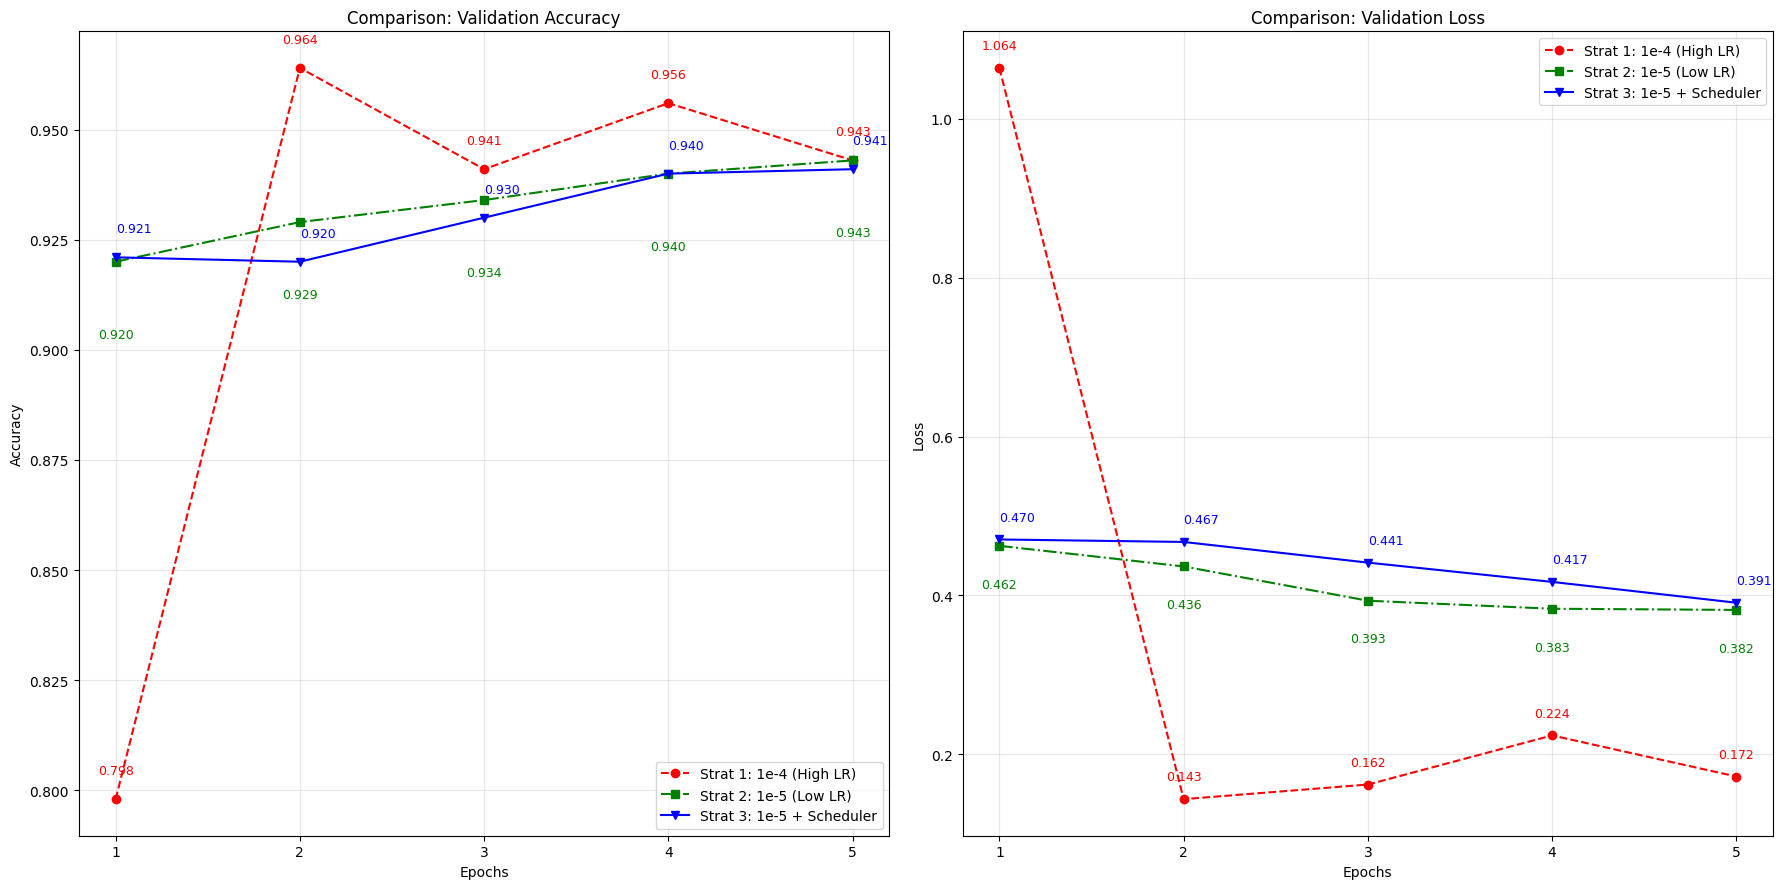

In [23]:
import matplotlib.pyplot as plt

# Epochs
epochs = range(1, 6)
plt.figure(figsize=(18, 9))

# Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, history_1.history['val_accuracy'], 'ro--', label='Strat 1: 1e-4 (High LR)')
plt.plot(epochs, history_2.history['val_accuracy'], 'gs-.', label='Strat 2: 1e-5 (Low LR)')
plt.plot(epochs, history_3.history['val_accuracy'], 'bv-', label='Strat 3: 1e-5 + Scheduler')

# mark
for i, val in enumerate(history_1.history['val_accuracy']):
    plt.text(epochs[i], val + 0.005, f'{val:.3f}', color='red', fontsize=9, ha='center', va='bottom')
for i, val in enumerate(history_2.history['val_accuracy']):
    plt.text(epochs[i], val - 0.015, f'{val:.3f}', color='green', fontsize=9, ha='center', va='top')
for i, val in enumerate(history_3.history['val_accuracy']):
    plt.text(epochs[i], val + 0.005, f'{val:.3f}', color='blue', fontsize=9, ha='left', va='bottom')

plt.title('Comparison: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs) 
plt.legend()
plt.grid(True, alpha=0.3)

# Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history_1.history['val_loss'], 'ro--', label='Strat 1: 1e-4 (High LR)')
plt.plot(epochs, history_2.history['val_loss'], 'gs-.', label='Strat 2: 1e-5 (Low LR)')
plt.plot(epochs, history_3.history['val_loss'], 'bv-', label='Strat 3: 1e-5 + Scheduler')

# mark
for i, val in enumerate(history_1.history['val_loss']):
    plt.text(epochs[i], val + 0.02, f'{val:.3f}', color='red', fontsize=9, ha='center', va='bottom')
for i, val in enumerate(history_2.history['val_loss']):
    plt.text(epochs[i], val - 0.04, f'{val:.3f}', color='green', fontsize=9, ha='center', va='top')
for i, val in enumerate(history_3.history['val_loss']):
    plt.text(epochs[i], val + 0.02, f'{val:.3f}', color='blue', fontsize=9, ha='left', va='bottom')

plt.title('Comparison: Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Strategy Selection Analysis
1. **Strategy 1** ($10^{-4}$) achieved the highest transient accuracy (0.964), but displayed significant volatility in Validation Loss, which increased from 0.143 to 0.224. This suggests that a high learning rate causes the model to overshoot the local minima.
2.  **Strategy 2 and 3** showed nearly identical steady improvement. **Strategy 3** ($10^{-5}$ + Scheduler) maintained the most consistent downward trend in Loss (0.470 to 0.391), making it the most reliable candidate for long-term training.
3. The sudden spike in **Strategy 1**'s loss indicates the onset of early `overfitting`. So **Strategy 3** is selected as the **best** due to its balanced performance and adaptive nature.

### Final Model Training (Deep Dive)

In [ ]:
# reset the model
def build_vgg_finetune():
    conv_base = keras.applications.vgg16.VGG16(
        weights="imagenet", include_top=False, input_shape=(180, 180, 3))
    
    conv_base.trainable = True
    for layer in conv_base.layers[:-4]:
        layer.trainable = False
        
    inputs = keras.Input(shape=(180, 180, 3))
    x = keras.applications.vgg16.preprocess_input(inputs) 
    x = conv_base(x)
    x = layers.Flatten()(x)
    x = layers.Dense(VGG_DENSE_UNITS, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs)

# create the final model
final_vgg_model = build_vgg_finetune()

In [28]:

final_vgg_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    metrics=["accuracy"])

# set Callbacks (Scheduler + Checkpoint)
callbacks_final = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=2, verbose=1),
    keras.callbacks.ModelCheckpoint(
        filepath="models/best_vgg_model.keras", 
        save_best_only=True, 
        monitor="val_loss")
]

# training the final model
print("Starting Final Deep Training with Champion Strategy...")
history_vgg_final = final_vgg_model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    callbacks=callbacks_final)

Starting Final Deep Training with Champion Strategy...
Epoch 1/10
63/63 [==============================] - 74s 1s/step - loss: 0.9242 - accuracy: 0.8809 - val_loss: 0.4209 - val_accuracy: 0.9350 - lr: 1.0000e-05
Epoch 2/10
63/63 [==============================] - 74s 1s/step - loss: 0.0263 - accuracy: 0.9920 - val_loss: 0.3989 - val_accuracy: 0.9380 - lr: 1.0000e-05
Epoch 3/10
63/63 [==============================] - 74s 1s/step - loss: 0.0012 - accuracy: 0.9990 - val_loss: 0.3718 - val_accuracy: 0.9410 - lr: 1.0000e-05
Epoch 4/10
63/63 [==============================] - 73s 1s/step - loss: 4.3491e-04 - accuracy: 0.9995 - val_loss: 0.3549 - val_accuracy: 0.9490 - lr: 1.0000e-05
Epoch 5/10
63/63 [==============================] - 74s 1s/step - loss: 2.3199e-04 - accuracy: 1.0000 - val_loss: 0.3392 - val_accuracy: 0.9530 - lr: 1.0000e-05
Epoch 6/10
63/63 [==============================] - 74s 1s/step - loss: 1.1659e-04 - accuracy: 1.0000 - val_loss: 0.3311 - val_accuracy: 0.9560 - lr: 1.

### VGG16 Final Performance Visualization

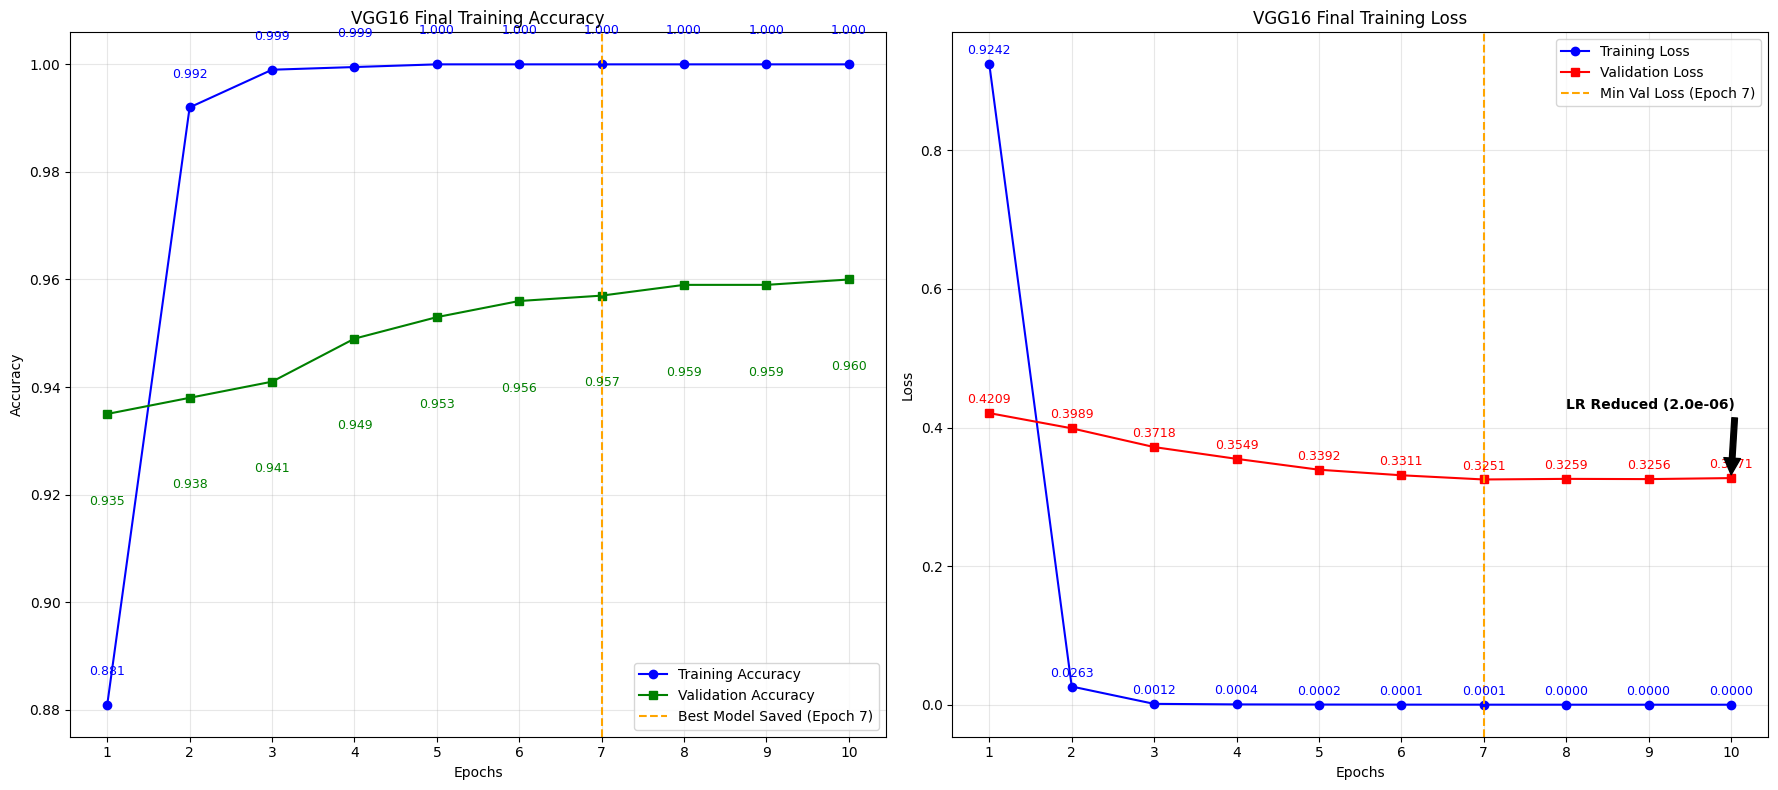

In [33]:
import matplotlib.pyplot as plt

acc = history_vgg_final.history['accuracy']
val_acc = history_vgg_final.history['val_accuracy']
loss = history_vgg_final.history['loss']
val_loss = history_vgg_final.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Best Epoch
# find the epoch with the lowest validation loss
min_val_loss = min(val_loss)
best_epoch = val_loss.index(min_val_loss) + 1

plt.figure(figsize=(18, 8))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs_range, val_acc, 'gs-', label='Validation Accuracy')

for i, (a, va) in enumerate(zip(acc, val_acc)):
    plt.text(epochs_range[i], a + 0.005, f'{a:.3f}', color='blue', ha='center', va='bottom', fontsize=9)
    plt.text(epochs_range[i], va - 0.015, f'{va:.3f}', color='green', ha='center', va='top', fontsize=9)

plt.axvline(x=best_epoch, color='orange', linestyle='--', label=f'Best Model Saved (Epoch {best_epoch})')
plt.title('VGG16 Final Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs_range)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'bo-', label='Training Loss')
plt.plot(epochs_range, val_loss, 'rs-', label='Validation Loss')

for i, (l, vl) in enumerate(zip(loss, val_loss)):
    plt.text(epochs_range[i], l + 0.01, f'{l:.4f}', color='blue', ha='center', va='bottom', fontsize=9)
    plt.text(epochs_range[i], vl + 0.01, f'{vl:.4f}', color='red', ha='center', va='bottom', fontsize=9)

# find learning rate
lr_history = history_vgg_final.history['lr']
change_indices = [i for i in range(1, len(lr_history)) if lr_history[i] < lr_history[i-1]]

if change_indices:
    idx = change_indices[0]
    plt.annotate(f'LR Reduced ({lr_history[idx]:.1e})', 
                 xy=(idx + 1, val_loss[idx]), 
                 xytext=(idx + 1 - 2, val_loss[idx] + 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05), 
                 fontsize=10, fontweight='bold')

plt.axvline(x=best_epoch, color='orange', linestyle='--', label=f'Min Val Loss (Epoch {best_epoch})')
plt.title('VGG16 Final Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Final Over-fitting Evaluation & Insights
1. Based on the 10-epoch fine-tuning process of the VGG16 model, Optimal Model Selection (**Epoch 7**)
2. The `ModelCheckpoint` callback successfully identified Epoch 7 as the peak performance point, where the Validation Loss reached its global minimum of `0.3251`.
3. A clear gap exists between the Training Accuracy (100% by Epoch 5) and the Validation Accuracy (plateauing at ~96%). In deep learning, when training loss continues to drop toward zero while validation loss begins to flatten or rise (as seen after Epoch 7), it indicates early-stage **over-fitting**. 
4. `ReduceLROnPlateau` detected a stagnation in validation loss during Epochs 8 and 9. Consequently, it automatically reduced the learning rate to $2 \times 10^{-6}$ for Epoch 10. This allowed the model to perform "micro-adjustments," which successfully stabilized the validation accuracy at its highest point (0.960).

## Explore Relative Performance

### Clear test set

In [44]:
import os
import PIL
from PIL import Image

# set path
test_dir = "data/dogs_vs_cats/test"

def clean_directory(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            # delete hidden files (like .DS_Store on macOS)
            if file.startswith('.'):
                os.remove(file_path)
                count += 1
                continue
            
            # Check if the image can be opened and verified
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                print(f'Removing corrupted/invalid file: {file_path}')
                os.remove(file_path)
                count += 1
    print(f"Cleanup finished. Removed {count} invalid files.")

# run the cleanup function
clean_directory(test_dir)

def force_rgb_conversion(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                try:
                    img = Image.open(file_path)
                    rgb_img = img.convert('RGB')
                    rgb_img.save(file_path, "JPEG") 
                    
                    count += 1
                    if count % 500 == 0:
                        print(f"Verified and processed {count} images...")
                        
                except Exception as e:
                    print(f"Serious error with {file_path}, removing file: {e}")
                    os.remove(file_path)
                    
    print(f"Finished! Total images unified to standard RGB: {count}")
    
# run the conversion function
force_rgb_conversion(test_dir)


test_dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(180, 180),
    batch_size=32)

Cleanup finished. Removed 0 invalid files.
Verified and processed 500 images...
Verified and processed 1000 images...
Verified and processed 1500 images...
Verified and processed 2000 images...
Finished! Total images unified to standard RGB: 2000
Found 2000 files belonging to 2 classes.


### Load Best Models & Evaluate Base Accuracy

In [45]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# load the models
model_vanilla = keras.models.load_model('models/best_vanilla_model.keras')
model_vgg = keras.models.load_model('models/best_vgg_model.keras')

# Accuracy in Test Set
print("Evaluating Vanilla CNN on Test Set...")
val_loss_1, val_acc_1 = model_vanilla.evaluate(test_dataset)

print("\nEvaluating VGG16 (Fine-tuned) on Test Set...")
val_loss_2, val_acc_2 = model_vgg.evaluate(test_dataset)

print(f"\nSummary Test Accuracy:")
print(f"Vanilla CNN: {val_acc_1:.4f}")
print(f"VGG16 Model: {val_acc_2:.4f}")

Evaluating Vanilla CNN on Test Set...
63/63 [==============================] - 4s 64ms/step - loss: 0.5859 - accuracy: 0.6995

Evaluating VGG16 (Fine-tuned) on Test Set...
63/63 [==============================] - 40s 635ms/step - loss: 0.3939 - accuracy: 0.9485

Summary Test Accuracy:
Vanilla CNN: 0.6995
VGG16 Model: 0.9485


### Comprehensive Evaluation Metrics

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating predictions for both models...")

# load all test images and labels into memory for evaluation
test_images, test_labels = [], []
for img, label in test_dataset:
    test_images.append(img)
    test_labels.append(label)

test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

# Probability
pred_vanilla = model_vanilla.predict(test_images)
pred_vgg = model_vgg.predict(test_images)

# transform probabilities to binary predictions ((0 = Cat, 1 = Dog))
y_pred_vanilla = (pred_vanilla > 0.5).astype(int)
y_pred_vgg = (pred_vgg > 0.5).astype(int)

Generating predictions for both models...
63/63 [==============================] - 39s 622ms/step


* Confusion Matrix

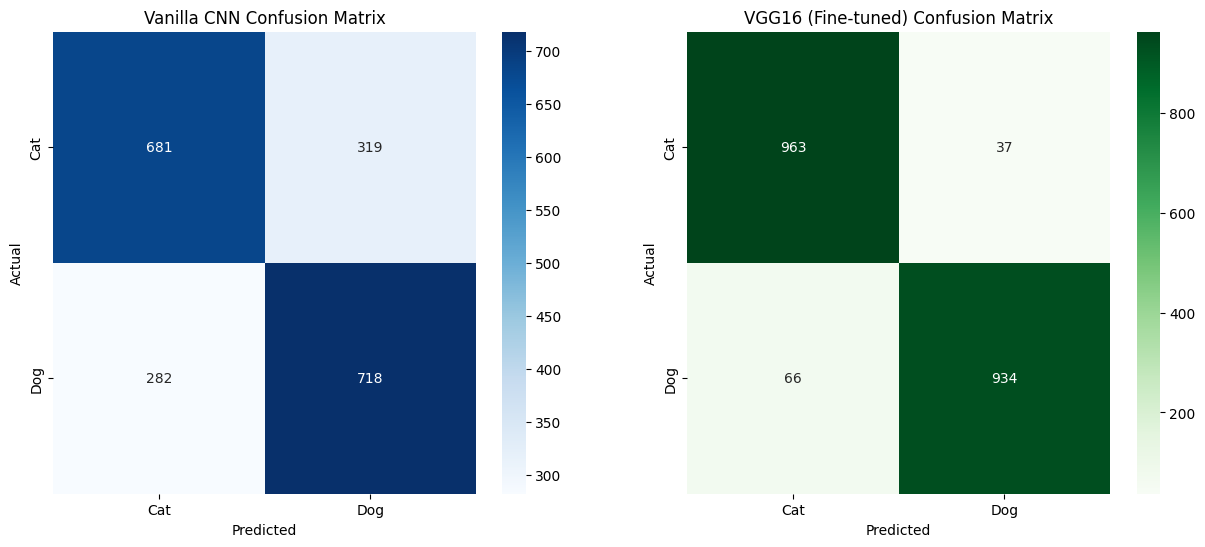

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(confusion_matrix(test_labels, y_pred_vanilla), annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Vanilla CNN Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')
ax[0].set_xticklabels(['Cat', 'Dog'])
ax[0].set_yticklabels(['Cat', 'Dog'])

sns.heatmap(confusion_matrix(test_labels, y_pred_vgg), annot=True, fmt='d', ax=ax[1], cmap='Greens')
ax[1].set_title('VGG16 (Fine-tuned) Confusion Matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')
ax[1].set_xticklabels(['Cat', 'Dog'])
ax[1].set_yticklabels(['Cat', 'Dog'])
plt.show()

* Classification Report (Precision, Recall, F1)

In [ ]:
print("\n" + "="*20 + " Vanilla CNN Report " + "="*20)
print(classification_report(test_labels, y_pred_vanilla, target_names=['Cat', 'Dog']))

print("\n" + "="*20 + " VGG16 (Fine-tuned) Report " + "="*20)
print(classification_report(test_labels, y_pred_vgg, target_names=['Cat', 'Dog']))


==================== Vanilla CNN Report ====================
              precision    recall  f1-score   support

         Cat       0.71      0.68      0.69      1000
         Dog       0.69      0.72      0.70      1000

    accuracy                           0.70      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.70      0.70      0.70      2000


==================== VGG16 (Fine-tuned) Report ====================
              precision    recall  f1-score   support

         Cat       0.94      0.96      0.95      1000
         Dog       0.96      0.93      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



* Precision-Recall Curve

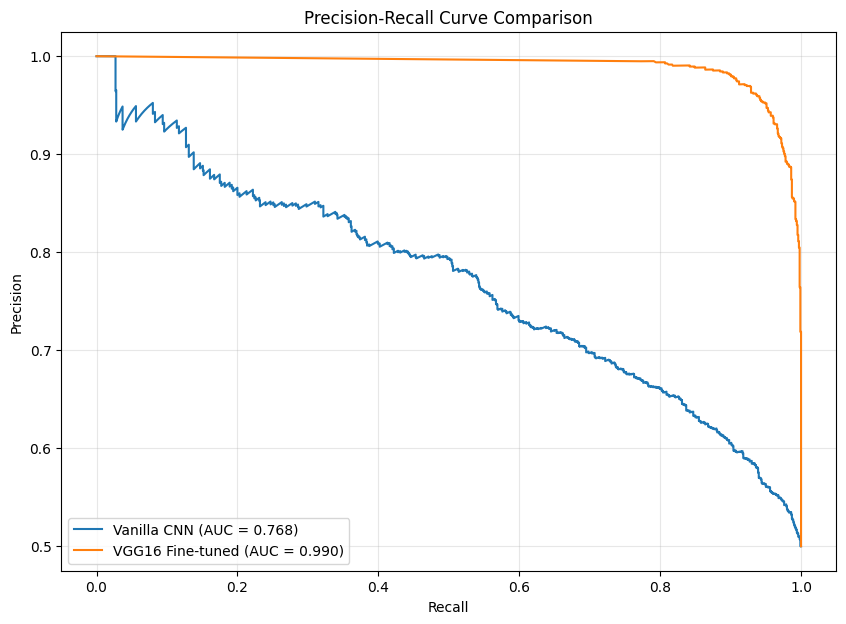

In [51]:
precision_v1, recall_v1, _ = precision_recall_curve(test_labels, pred_vanilla)
precision_v2, recall_v2, _ = precision_recall_curve(test_labels, pred_vgg)

plt.figure(figsize=(10, 7))
plt.plot(recall_v1, precision_v1, label=f'Vanilla CNN (AUC = {auc(recall_v1, precision_v1):.3f})')
plt.plot(recall_v2, precision_v2, label=f'VGG16 Fine-tuned (AUC = {auc(recall_v2, precision_v2):.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

* Explore Specific Failure Examples

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.0691346..254.88249].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..220.125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..240.91614].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [16.655588..254.99992].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Total incorrect predictions by VGG16: 103


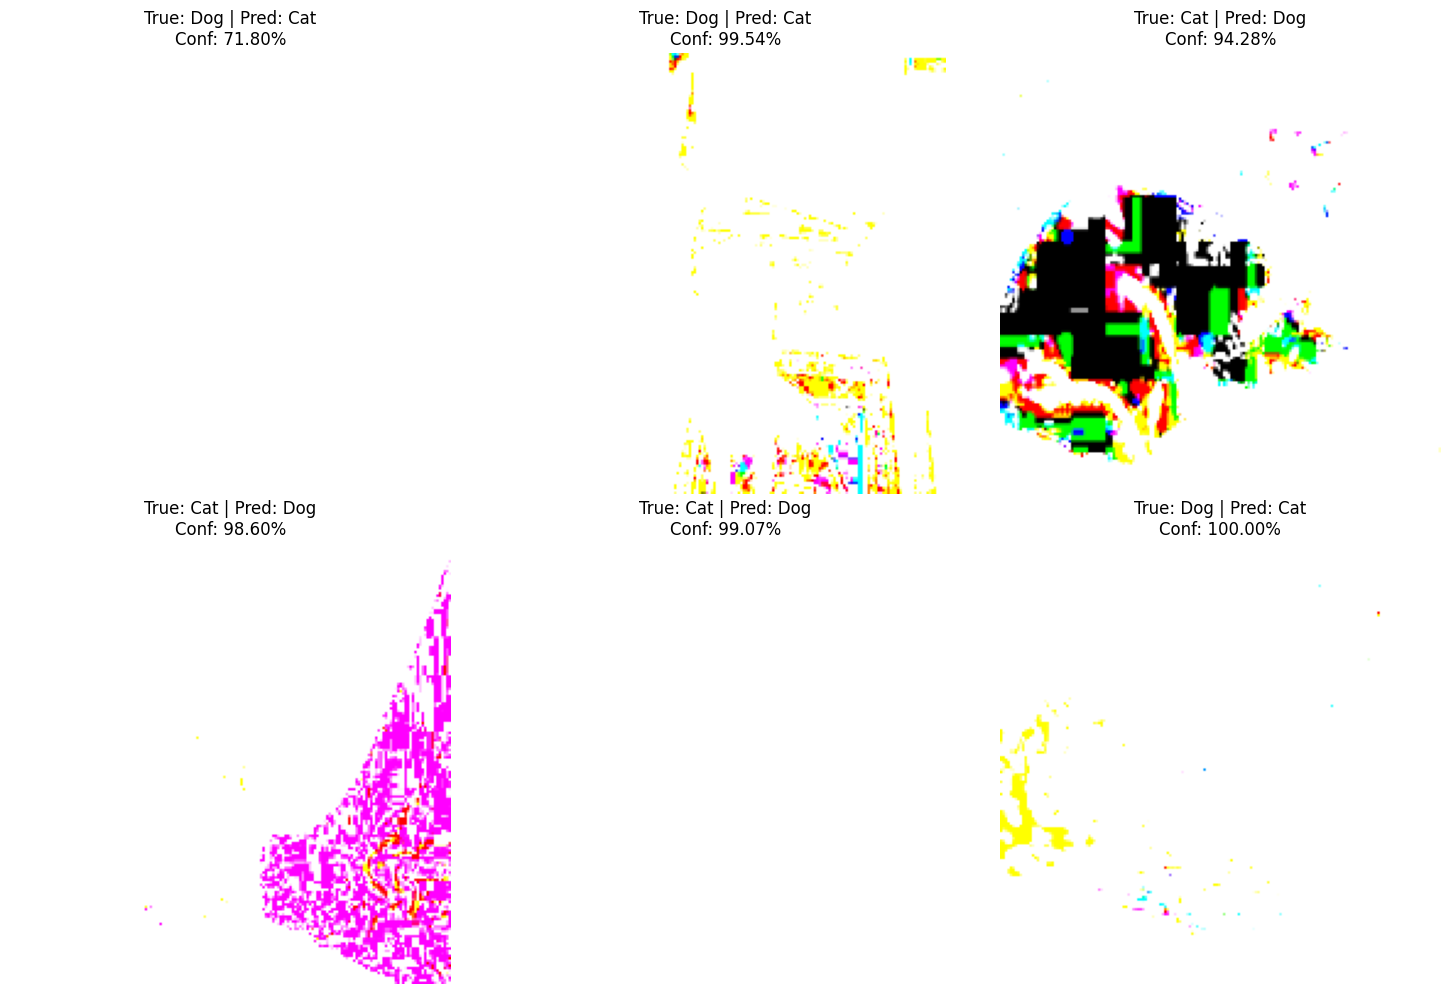

In [53]:
# find (0 or 1)
y_pred_vgg = (pred_vgg > 0.5).astype(int).flatten()
y_true = test_labels.astype(int)

# find indices of incorrect predictions
incorrect_indices = np.where(y_pred_vgg != y_true)[0]

print(f"Total incorrect predictions by VGG16: {len(incorrect_indices)}")

# select the first 6 incorrect examples to display
plt.figure(figsize=(15, 10))
for i, idx in enumerate(incorrect_indices[:6]):
    plt.subplot(2, 3, i + 1)
    plt.imshow(test_images[idx])
    
    true_label = "Dog" if y_true[idx] == 1 else "Cat"
    pred_label = "Dog" if y_pred_vgg[idx] == 1 else "Cat"
    confidence = pred_vgg[idx][0] if y_pred_vgg[idx] == 1 else 1 - pred_vgg[idx][0]
    
    plt.title(f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.2%}")
    plt.axis('off')

plt.tight_layout()
plt.show()